In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ctg-studies.csv")

In [2]:
# Dataset overview

print("Dataset shape:", df.shape)

display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (61215, 18)


,NCT Number,Study Status,Brief Summary,Conditions,Interventions,Sponsor,Collaborators,Sex,Age,Phases,Enrollment,Funder Type,Study Type,Study Design,Start Date,Primary Completion Date,Completion Date,Locations
0,NCT05185284,COMPLETED,This is open-labe randomized multicenter compa...,COVID-19,DRUG: Favipiravir|DRUG: Favipiravir|DRUG: Remd...,"Promomed, LLC",Solyur Pharmaceuticals Group,ALL,"ADULT, OLDER_ADULT",PHASE3,217.0,OTHER,INTERVENTIONAL,Allocation: RANDOMIZED | Intervention Model: P...,2021-08-11,2021-12-30,2021-12-30,"Regional budgetary health care institution ""Iv..."
1,NCT04752033,COMPLETED,This research study is being done to determine...,"Colorectal Surgery|Pain, Postoperative|Analges...",DRUG: Morphine|DRUG: Hydromorphone,Mayo Clinic,NaN,ALL,"ADULT, OLDER_ADULT",PHASE4,80.0,OTHER,INTERVENTIONAL,Allocation: RANDOMIZED | Intervention Model: S...,2021-03-10,2023-02-17,2023-02-17,"Mayo Clinic in Rochester, Rochester, Minnesota..."
2,NCT06241352,COMPLETED,The results of previous studies conducted by o...,Advanced Pancreatic Cancer,DRUG: statin addition to chemotherapy,Changhai Hospital,NaN,ALL,"ADULT, OLDER_ADULT",PHASE2,42.0,OTHER,INTERVENTIONAL,Allocation: NA | Intervention Model: SINGLE_GR...,2024-03-20,2025-04-30,2025-04-30,"Changhai Hospital, Shanghai, Shanghai Municipa..."
3,NCT03988933,COMPLETED,Rationale:\n\nShorter regimens of high dose da...,Latent Tuberculosis,DRUG: Rifampin double dose|DRUG: Rifampin trip...,McGill University Health Centre/Research Insti...,Canadian Institutes of Health Research (CIHR),ALL,"CHILD, ADULT, OLDER_ADULT",PHASE2,1368.0,OTHER,INTERVENTIONAL,Allocation: RANDOMIZED | Intervention Model: P...,2019-09-20,2023-01-31,2024-12-31,"Unviversity of Calgary, Calgary, Alberta, Cana..."
4,NCT06149247,COMPLETED,The objective of this clinical study is to com...,Cutaneous T-Cell Lymphoma/Mycosis Fungoides,DRUG: Hypericin|DRUG: Mechlorethamine Topical Gel,Soligenix,NaN,ALL,"ADULT, OLDER_ADULT",PHASE2,10.0,INDUSTRY,INTERVENTIONAL,Allocation: RANDOMIZED | Intervention Model: P...,2023-12-05,2024-05-31,2024-06-27,"Rochester Skin Lymphoma Medical Group, Fairpor..."



Column names:
['NCT Number', 'Study Status', 'Brief Summary', 'Conditions', 'Interventions', 'Sponsor', 'Collaborators', 'Sex', 'Age', 'Phases', 'Enrollment', 'Funder Type', 'Study Type', 'Study Design', 'Start Date', 'Primary Completion Date', 'Completion Date', 'Locations']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61215 entries, 0 to 61214
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   NCT Number               61215 non-null  object 
 1   Study Status             61215 non-null  object 
 2   Brief Summary            61215 non-null  object 
 3   Conditions               61215 non-null  object 
 4   Interventions            61215 non-null  object 
 5   Sponsor                  61215 non-null  object 
 6   Collaborators            18784 non-null  object 
 7   Sex                      61199 non-null  object 
 8   Age                      61215 non-null  objec

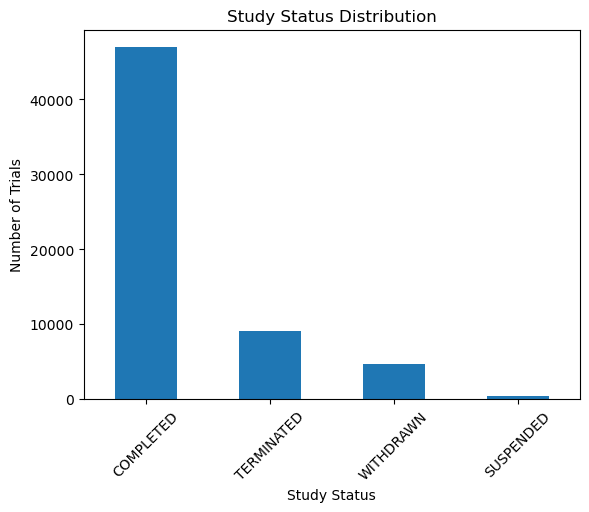

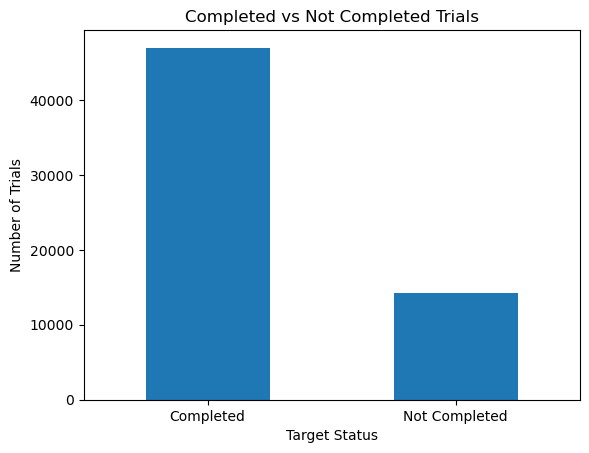

target_status
Completed        76.73
Not Completed    23.27
Name: proportion, dtype: float64

In [3]:
#Study status distribution
# Chart 1: Study Status distribution
df["Study Status"].value_counts().plot(
    kind="bar",
    title="Study Status Distribution"
)

plt.xlabel("Study Status")
plt.ylabel("Number of Trials")
plt.xticks(rotation=45)
plt.show()


# Create target_status
df["target_status"] = df["Study Status"].map({
    "COMPLETED": 1,
    "TERMINATED": 0,
    "WITHDRAWN": 0,
    "SUSPENDED": 0
})

target_labels = df["target_status"].map({
    1: "Completed",
    0: "Not Completed"
})


# Chart 2: Completed vs Not Completed
target_labels.value_counts().plot(
    kind="bar",
    title="Completed vs Not Completed Trials"
)

plt.xlabel("Target Status")
plt.ylabel("Number of Trials")
plt.xticks(rotation=0)
plt.show()


# Percentage table
target_labels.value_counts(normalize=True).mul(100).round(2)

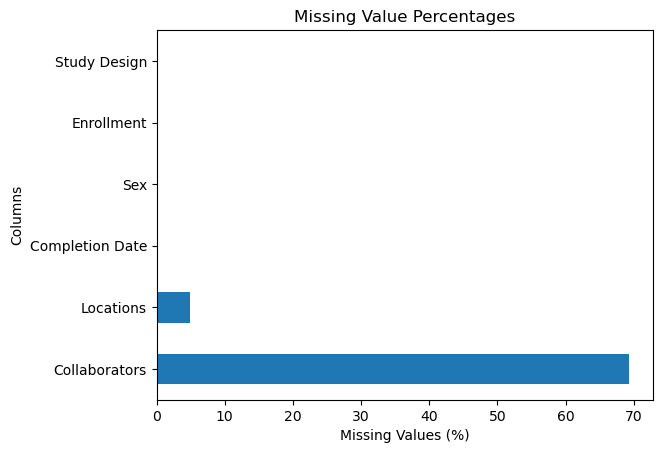

In [4]:
# Missing values: show only columns that have missing values

missing = df.isnull().mean().sort_values(ascending=False) * 100

missing = missing[missing > 0]

missing.plot(
    kind="barh",
    title="Missing Value Percentages"
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Columns")
plt.show()

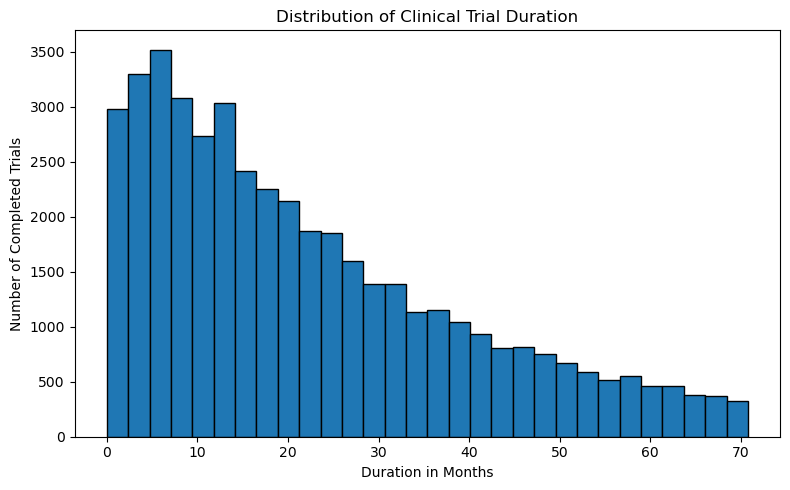

95th percentile duration value: 70.8


count    46845.00
mean        25.40
std         21.99
min          0.03
25%          8.57
50%         18.96
75%         36.10
max        133.87
Name: duration_months, dtype: float64

In [5]:
# Duration distribution for completed trials only

# Convert date columns to datetime format
df["Start Date"] = pd.to_datetime(df["Start Date"], errors="coerce", format="mixed")
df["Completion Date"] = pd.to_datetime(df["Completion Date"], errors="coerce", format="mixed")

# Create duration_months column
df["duration_months"] = (
    (df["Completion Date"] - df["Start Date"]).dt.days / 30.44
)

# Keep only completed trials with valid positive duration
duration_df = df[
    (df["target_status"] == 1) &
    (df["duration_months"].notna()) &
    (df["duration_months"] > 0)
].copy()

# 95th percentile used only for display range
duration_limit = duration_df["duration_months"].quantile(0.95)

plt.figure(figsize=(8, 5))

plt.hist(
    duration_df["duration_months"],
    bins=30,
    range=(0, duration_limit),
    edgecolor="black"
)

plt.title("Distribution of Clinical Trial Duration")
plt.xlabel("Duration in Months")
plt.ylabel("Number of Completed Trials")

plt.tight_layout()
plt.show()

print("95th percentile duration value:", round(duration_limit, 2))
display(duration_df["duration_months"].describe().round(2))

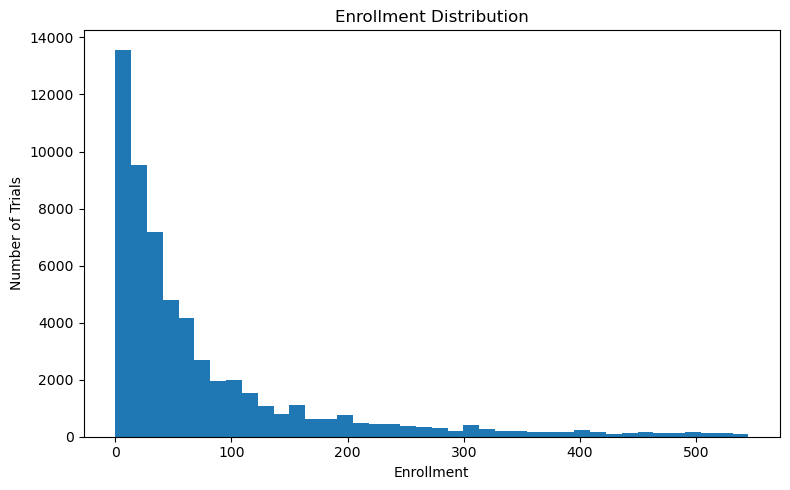

95th percentile enrollment value: 545.0


count     61208.00
mean        256.38
std        5692.46
min           0.00
25%          16.00
50%          42.00
75%         109.00
max      864493.00
Name: Enrollment, dtype: float64

In [6]:
# Enrollment distribution using 95th percentile display range

df["Enrollment"] = pd.to_numeric(df["Enrollment"], errors="coerce")

enrollment_limit = df["Enrollment"].quantile(0.95)

plt.figure(figsize=(8, 5))

plt.hist(
    df["Enrollment"].dropna(),
    bins=40,
    range=(0, enrollment_limit)
)

plt.title("Enrollment Distribution")
plt.xlabel("Enrollment")
plt.ylabel("Number of Trials")

plt.tight_layout()
plt.show()

print("95th percentile enrollment value:", round(enrollment_limit, 2))
display(df["Enrollment"].describe().round(2))